## Clustering Project

### Define Dataset

In [1]:
import pandas as pd

df = pd.read_csv("info_dataset.csv")

print(df.shape)
df.tail(3)

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Preprocessing

In [3]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [4]:
# map gender categories to numeric values (Male=0, Female=1).
df["new_Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),new_Gender
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


### KMeans Clusterer

In [5]:
# We do not use the Gender feature in the K-Means algorithm because it is a categorical feature, even if it is encoded with numeric values.
x_km = df.values[:, 2:5]
x_km[:5]

array([[19, 15, 39],
       [21, 15, 81],
       [20, 16, 6],
       [23, 16, 77],
       [31, 17, 40]], dtype=object)

In [6]:
from sklearn.preprocessing import StandardScaler

x_scaled_km = StandardScaler().fit_transform(x_km) # Since the K-Means algorithm is distance-based, the data must be normalized.

x_scaled_km[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


interies = [] # We use the inertia parameter to plot the elbow method chart.
silhouette = [] 
mapping = {} # This dictionary stores the inertia and silhouette score for each cluster (k).
K = range(2, 11) # We consider cluster numbers from 2 to 11 and evaluate the inertia and silhouette score for each one.

for k in K:
    km_model = KMeans(n_clusters=k, init="k-means++", n_init=10).fit(x_scaled_km)
    km_labels = km_model.labels_

    interies.append(km_model.inertia_)
    silhouette.append(silhouette_score(x_scaled_km, km_labels)) # The silhouette score evaluates the compactness within clusters and the separation between clusters.
    mapping[k] = (interies[-1], silhouette[-1])

for n_cluster = 2 : inertia == 389.3861889564371 | average slihouette score == 0.33547192894004574
for n_cluster = 3 : inertia == 295.2122461555488 | average slihouette score == 0.357793388710272
for n_cluster = 4 : inertia == 205.22514747675922 | average slihouette score == 0.4039582785148566
for n_cluster = 5 : inertia == 168.24758017556837 | average slihouette score == 0.41664341513732767
for n_cluster = 6 : inertia == 133.88887021131023 | average slihouette score == 0.4268547747113388
for n_cluster = 7 : inertia == 117.01155455889811 | average slihouette score == 0.417231894954916
for n_cluster = 8 : inertia == 104.15429882343581 | average slihouette score == 0.4076384257125318
for n_cluster = 9 : inertia == 93.37714722233073 | average slihouette score == 0.38858916244320996
for n_cluster = 10 : inertia == 82.10686281205294 | average slihouette score == 0.4061806494842442


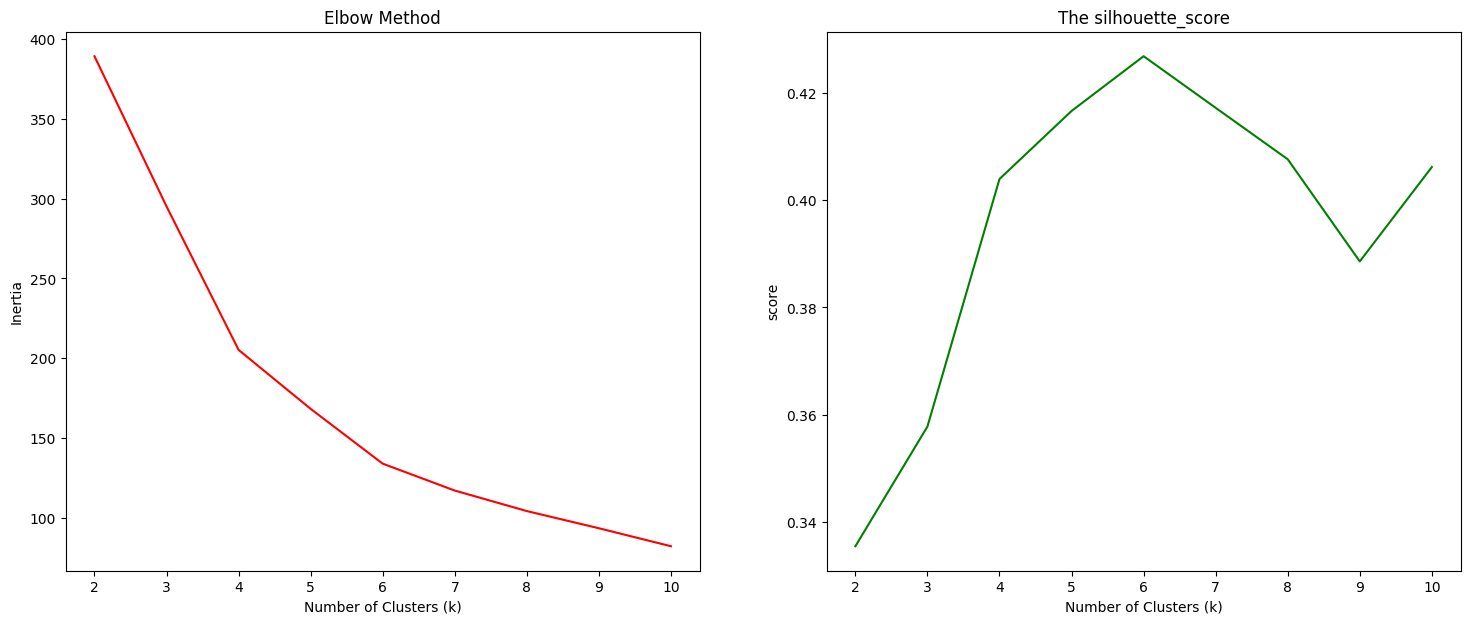

In [8]:
# We use the silhouette score and the elbow method plots to determine the optimal number of clusters (best k).

for key, val in mapping.items():
    print(f"for n_cluster = {key} : inertia == {val[0]} | average slihouette score == {val[1]}")

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

ax1.plot(K, interies, color="red")
ax2.plot(K, silhouette, color="green")

ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")

ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("score")
ax2.set_title("The silhouette_score")
plt.show()

In [9]:
# The value of k that has the highest silhouette score and corresponds to the elbow point in the Elbow Method chart is the best choice for the number of clusters.

km_model = KMeans(n_clusters=6, init="k-means++", n_init=10).fit(x_scaled_km) # According to the two plots above, the optimal number of clusters is 6.

In [10]:
km_labels = km_model.labels_
km_labels

array([5, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 1, 5, 4, 2,
       4, 5, 1, 2, 2, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 2,
       1, 1, 2, 2, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 1, 2,
       2, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 3, 2, 3, 0, 3, 0, 3, 0, 3,
       2, 3, 0, 3, 0, 3, 2, 3, 0, 3, 2, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 1, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3], dtype=int32)

In [11]:
km_clusters = km_model.cluster_centers_
km_clusters

array([[ 0.22171558,  1.08322527, -1.29005223],
       [ 1.25472096, -0.24021294, -0.04399777],
       [-0.86515664, -0.13196835, -0.08043031],
       [-0.44191719,  0.99158305,  1.23950275],
       [ 0.47895722, -1.30822992, -1.19644353],
       [-0.99396865, -1.34734766,  1.06404834]])

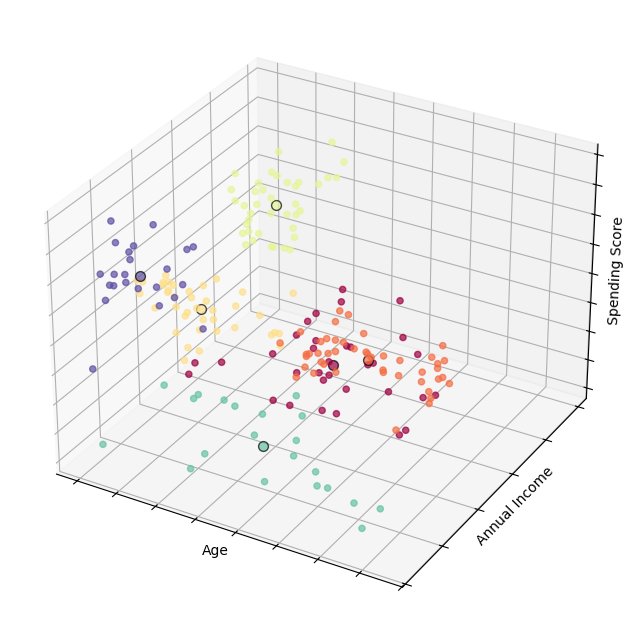

In [12]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d') # Add a 3D subplot to the figure

colors = plt.cm.Spectral(np.linspace(0, 1, len(set(km_labels))))

for k, color in zip(range(len(km_clusters)), colors):

    this_members = (km_labels == k) # Select datapoints belonging to cluster k
    cluster_center = km_clusters[k] # Select the centroid of this cluster.


    ax.scatter(
        x_scaled_km[this_members, 0], # Age feature
        x_scaled_km[this_members, 1], # Annual Income feature
        x_scaled_km[this_members, 2], # Spending Score feature
        color=color,
        marker="o",
        alpha=0.7
        )

    ax.scatter(
        cluster_center[0],
        cluster_center[1],
        cluster_center[2],
        marker="o",
        color=color,
        edgecolor="black", # Set the marker edge (outline) color to black
        s=50,
        alpha=0.7
        )

ax.set_xlabel("Age", labelpad=-10) # Labelpad adjust the distance between the label and the axis (فاصله بین برچسب محور و محور را تنظیم می‌کند)
ax.set_ylabel("Annual Income", labelpad=-10)
ax.set_zlabel("Spending Score", labelpad=-10)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
plt.show()

In [13]:
silhouette_score(x_scaled_km, km_labels)

0.4284167762892593

### Hierarchical Clusterer

In [14]:
# For hierarchical clustering, we can use categorical features if they have been converted into numerical values.

x_hier = df.values[:, 2:] # We use "new_Gender" feature which is categorical and numerical.
x_hier[:5]

array([[19, 15, 39, 0],
       [21, 15, 81, 0],
       [20, 16, 6, 1],
       [23, 16, 77, 1],
       [31, 17, 40, 1]], dtype=object)

In [15]:
from sklearn.metrics.pairwise import euclidean_distances

dist_matrix = euclidean_distances(x_hier, x_hier) # Use the euclidean_distances function to obtain the proximity matrix.
dist_matrix

array([[  0.        ,  42.04759208,  33.04542328, ..., 117.1110584 ,
        124.47489707, 130.15759678],
       [ 42.04759208,   0.        ,  75.01999733, ..., 111.7631424 ,
        137.74614332, 122.34786471],
       [ 33.04542328,  75.01999733,   0.        , ..., 129.8807145 ,
        122.18837915, 143.77412841],
       ...,
       [117.1110584 , 111.7631424 , 129.8807145 , ...,   0.        ,
         57.07013229,  14.35270009],
       [124.47489707, 137.74614332, 122.18837915, ...,  57.07013229,
          0.        ,  65.03076195],
       [130.15759678, 122.34786471, 143.77412841, ...,  14.35270009,
         65.03076195,   0.        ]], shape=(200, 200))

In [16]:
from scipy.cluster import hierarchy

z = hierarchy.linkage(dist_matrix, "complete") # Compute the linkage (hierarchical relationships) between the data points.

C:\Users\User\AppData\Local\Temp\ipykernel_7872\1417466887.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  z = hierarchy.linkage(dist_matrix, "complete") # Compute the linkage (hierarchical relationships) between the data points.


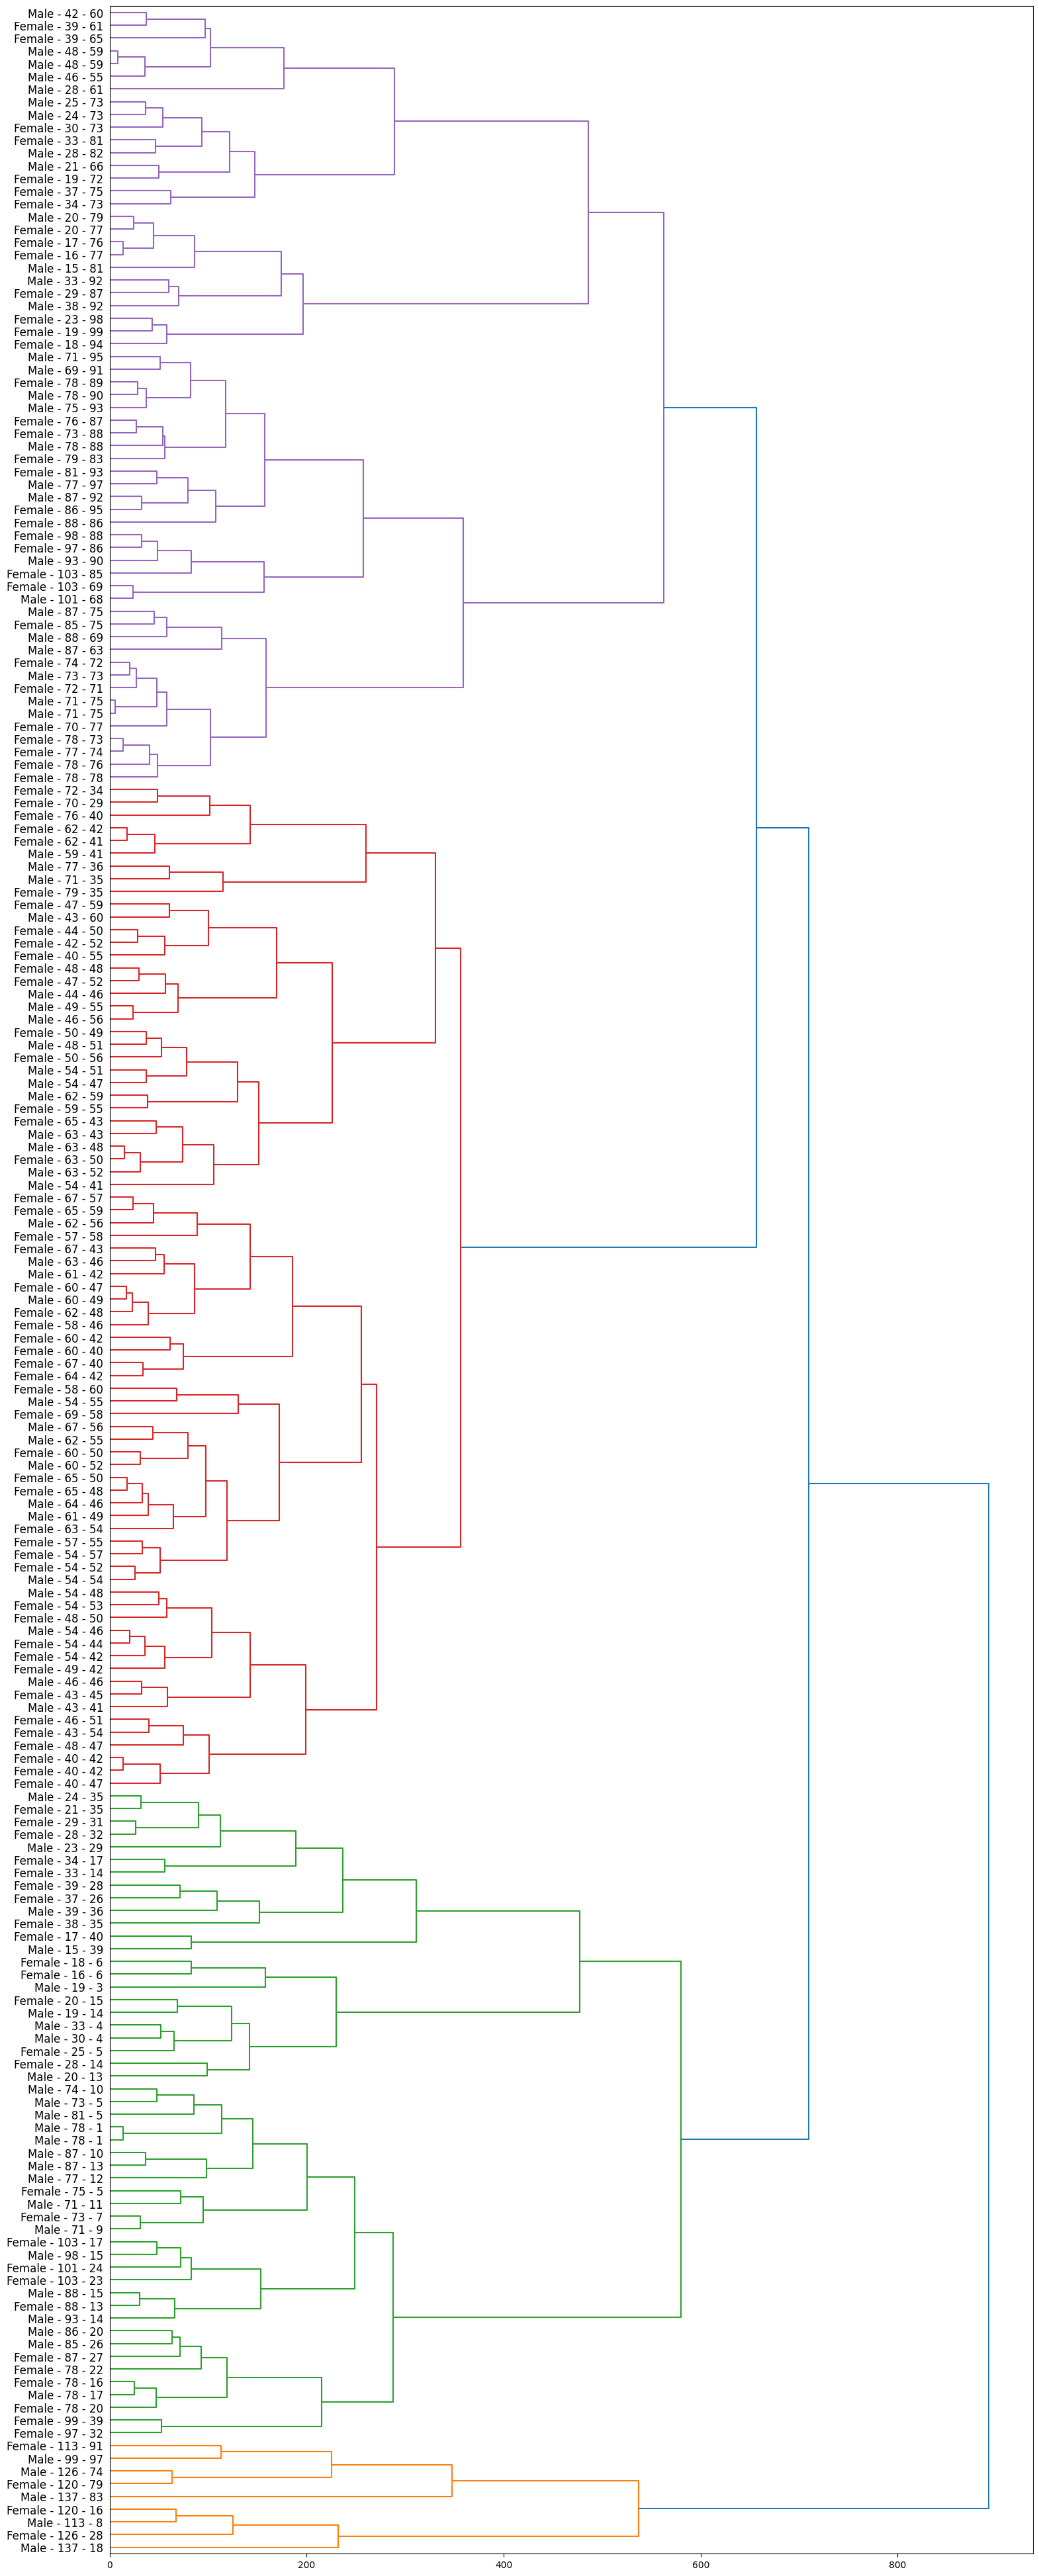

In [17]:
# Plot the hierarchy (dendrogram).
import pylab

fig = pylab.figure(figsize=(18, 50))

def llf(id):
    return "%s - %s - %s" % (df["Gender"][id], df["Annual Income (k$)"][id], df["Spending Score (1-100)"][id])

dendro = hierarchy.dendrogram(Z=z, leaf_label_func=llf, leaf_font_size=12, leaf_rotation=0, orientation="right")

In [18]:
from sklearn.cluster import AgglomerativeClustering

agglo_model = AgglomerativeClustering(n_clusters=6, linkage="complete") # Using the AgglomerativeClustering function to obtain the flat clusters.
agglo_model.fit(dist_matrix)

agglo_model.labels_

e:\project\Customer-Segmentation-ML\myvenv\Lib\site-packages\sklearn\cluster\_agglomerative.py:586: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


array([2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 1,
       3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 3, 5, 3, 5, 4, 5, 4, 5,
       3, 5, 4, 5, 4, 5, 4, 5, 4, 5, 3, 5, 4, 5, 3, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 3, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5,
       4, 5, 4, 5, 4, 5, 4, 5, 4, 0, 4, 5, 4, 5, 4, 5, 0, 0, 0, 0, 0, 0,
       0, 0])

In [19]:
df["cluster"] = agglo_model.labels_ # Add the cluster column to the dataframe.
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),new_Gender,cluster
0,1,Male,19,15,39,0,2
1,2,Male,21,15,81,0,1
2,3,Female,20,16,6,1,2
3,4,Female,23,16,77,1,1
4,5,Female,31,17,40,1,2


##### The silhouette score of this hierarchical clustering model is 0.41, indicating a moderate clustering quality with reasonably separated clusters

In [20]:
silhouette_score(x_hier, agglo_model.labels_)

0.41465962666813944

C:\Users\User\AppData\Local\Temp\ipykernel_7872\747199459.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset["Age"], subset["Annual Income (k$)"], s=subset["Spending Score (1-100)"]*10, c=color, label="cluster"+str(label), alpha=0.5)
C:\Users\User\AppData\Local\Temp\ipykernel_7872\747199459.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(subset["Age"], subset["Annual Income (k$)"], s=sub

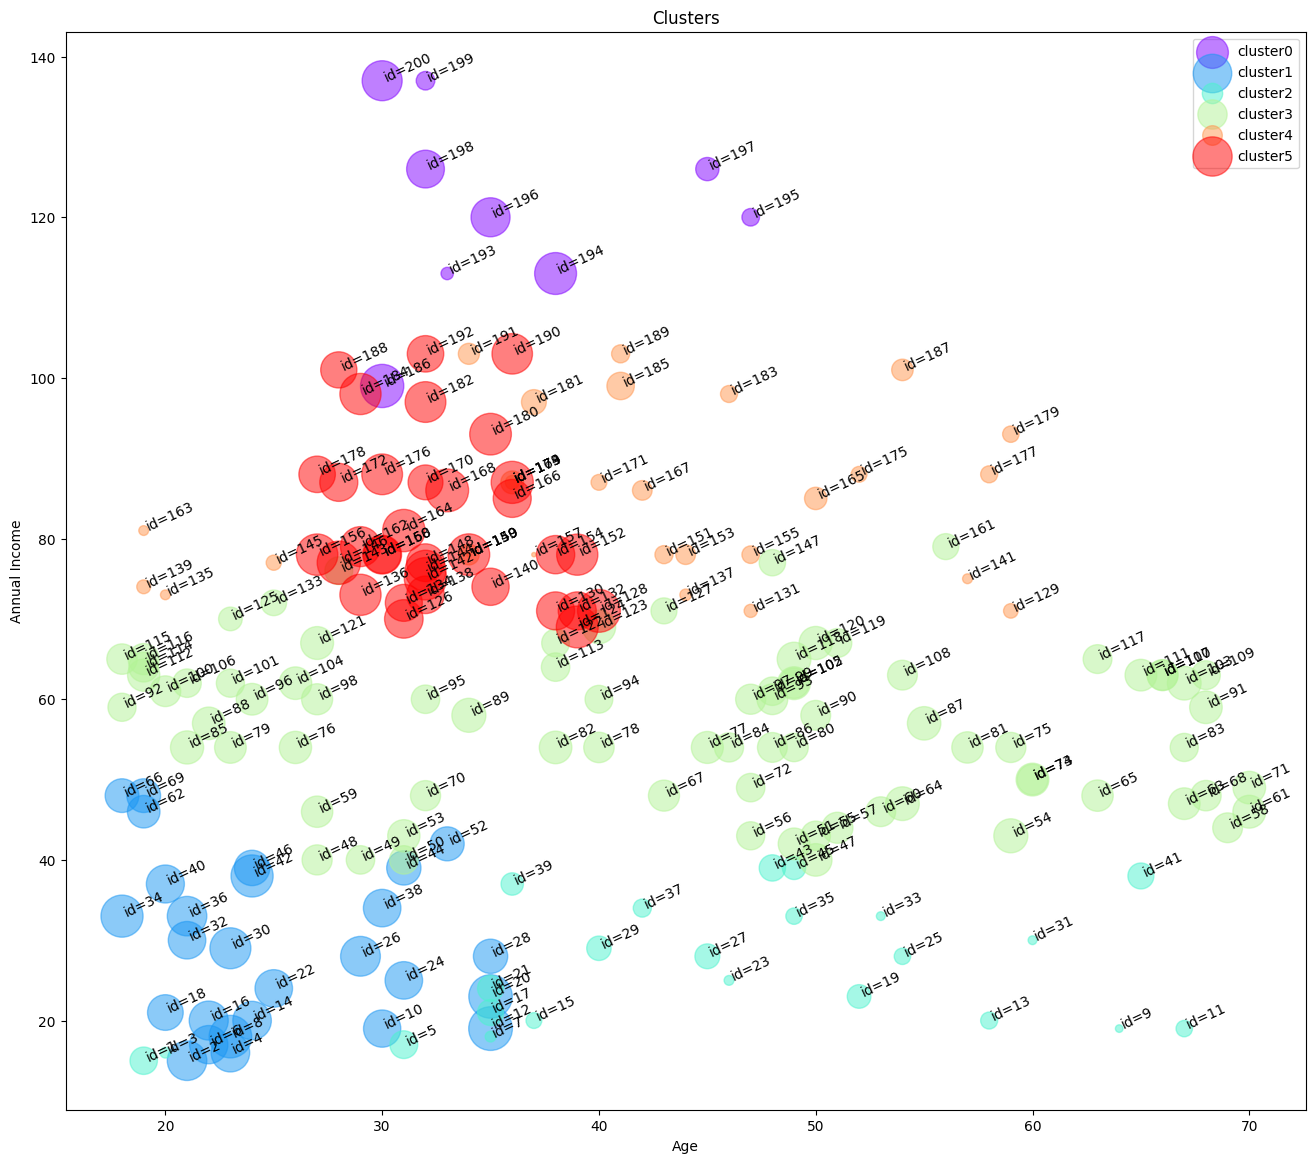

In [21]:
import matplotlib.cm as cm

n_cluster = max(agglo_model.labels_) + 1 # Because the label numbering starts from 0.
colors = cm.rainbow(np.linspace(0, 1, n_cluster)) # Generate distinct colors for each cluster using the rainbow colormap
cluster_labels = list(range(0, n_cluster)) # -> [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(16, 14))

for color, label in zip(colors, cluster_labels):
    subset = df[df.cluster == label] # Filter rows where the cluster value equals the current label(subset -> dataframe).
    
    for i in subset.index: # We iterate over the indices of the subset table; note that these indices are the same as the indices of the original table.
        # Write the "Customer ID" value at the coordinates defined by "Age" (x-axis) and "Annual Income" (y-axis).
        plt.text(subset["Age"][i], subset["Annual Income (k$)"][i], "id=" + str(subset["CustomerID"][i]), rotation=25)
    ''' Plot all data points with "Age" (x-axis) and "Annual Income" (y-axis), while the bubble size of each sample is determined by its "Spending Score".
    Since the loop iterates over one cluster at a time, all samples belonging to the same cluster are displayed with the same color. '''
    plt.scatter(subset["Age"], subset["Annual Income (k$)"], s=subset["Spending Score (1-100)"]*10, c=color, label="cluster"+str(label), alpha=0.5)


plt.legend()
plt.title('Clusters')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

In [22]:
# Stores the average Age, Annual Income, and Spending Score for each (cluster, Gender) group in mean_df
mean_df = df.groupby(["cluster", "Gender"])[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean() # The output is a DataFrame, not a Series.
mean_df

Age  Annual Income (k$)  Spending Score (1-100)
cluster Gender                                                       
0       Female  41.250000          119.750000               53.500000
        Male    31.400000          122.400000               56.000000
1       Female  25.857143           26.642857               79.142857
        Male    24.153846           32.000000               71.692308
2       Female  43.214286           27.357143               21.714286
        Male    48.333333           24.666667               19.666667
3       Female  41.040816           56.469388               48.061224
        Male    48.533333           57.166667               48.733333
4       Female  43.416667           88.333333               20.416667
        Male    39.625000           81.562500               11.500000
5       Female  31.736842           82.842105               81.315789
        Male    33.800000           80.400000               82.266667

C:\Users\User\AppData\Local\Temp\ipykernel_7872\1297558830.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(subset.loc[i][0], subset.loc[i][1], "Gender=" + str(i) + ", score=" + str(int(subset.loc[i][2])))


Text(0, 0.5, 'Annual Income')

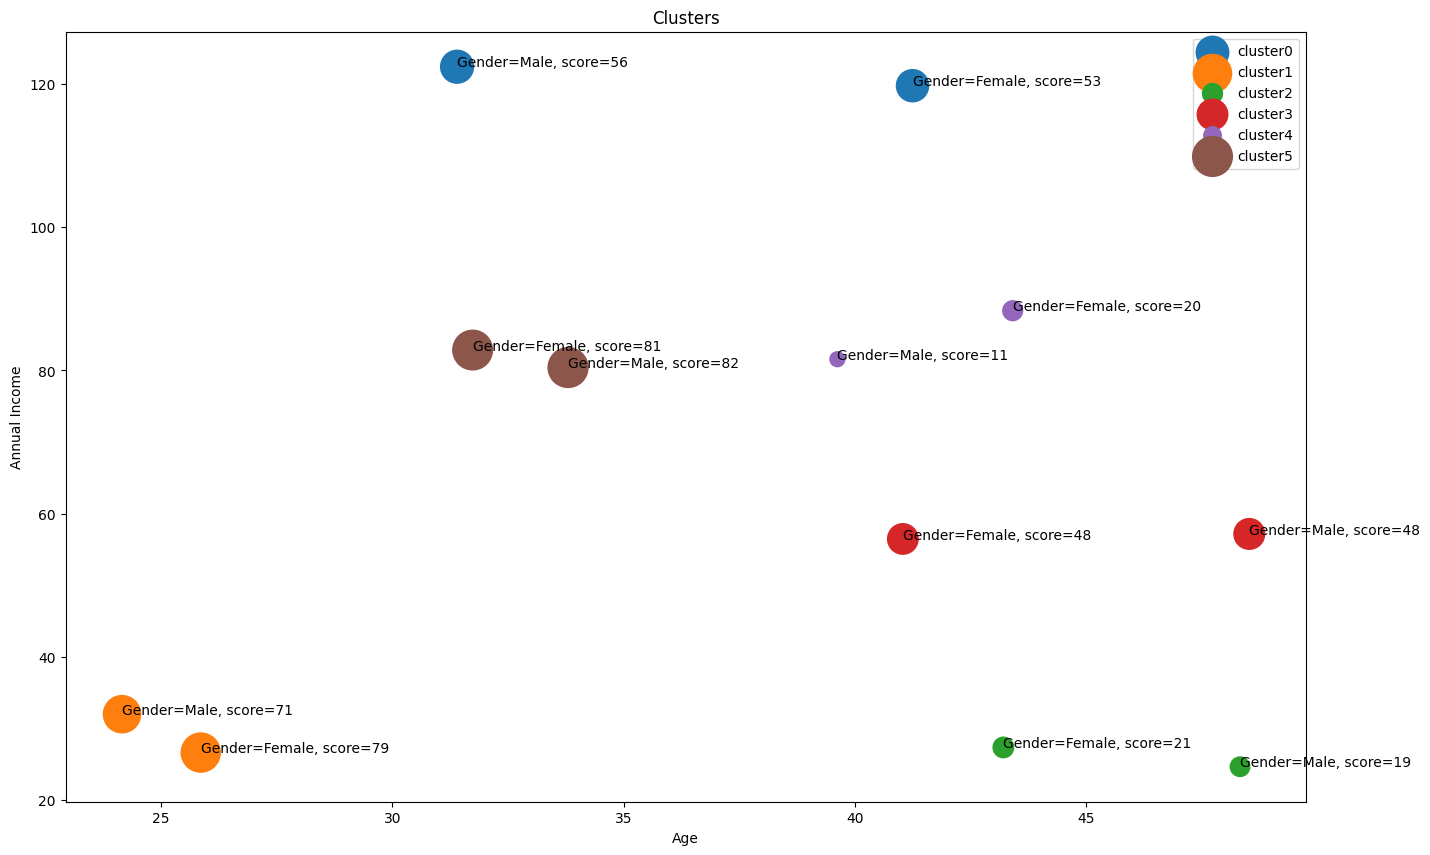

In [23]:
plt.figure(figsize=(16, 10))

for color, label in zip(colors, cluster_labels):
    subset = mean_df.loc[(label, ), ] # Select rows from mean_df where the cluster level of the index equals the given label
    
    for i in subset.index: # The value of i is either "Male" or "Female".
        ''' At the coordinates of the mean Age (x-axis) and mean Annual Income (y-axis),
        write the value of i (the gender) and the mean Spending Score of this group from the original dataframe. '''
        plt.text(subset.loc[i][0], subset.loc[i][1], "Gender=" + str(i) + ", score=" + str(int(subset.loc[i][2])))
    ''' Now we plot the mean Age and mean Annual Income of all groups on the chart,
    and the bubble size for each group represents that group's mean Spending Score. '''
    plt.scatter(subset.Age, subset["Annual Income (k$)"], s=subset["Spending Score (1-100)"] * 10, label="cluster" + str(label))

plt.legend()
plt.title('Clusters')
plt.xlabel('Age')
plt.ylabel('Annual Income')

### DBSCAN

In [24]:
# For DBSCAN, we also use only features that are not categorical, even if they have been converted to numeric values (Age column).
x_db = df.values[:, 2:5]
x_db[:5]

array([[19, 15, 39],
       [21, 15, 81],
       [20, 16, 6],
       [23, 16, 77],
       [31, 17, 40]], dtype=object)

In [25]:
x_scaled_db = StandardScaler().fit_transform(x_db) # We must normalize the data because this algorithm is distance-based.

x_scaled_db[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

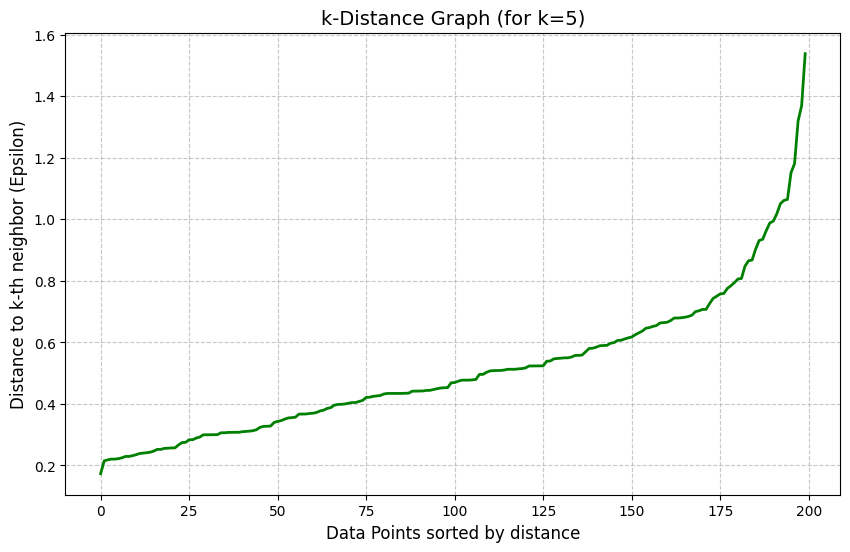

In [26]:
# This part of the code is used to find the best value for epsilon.
from sklearn.neighbors import NearestNeighbors

m_sample, k = 3 * 2, 5

neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(x_scaled_db) 

distances, indices = neigh.kneighbors(x_scaled_db) # We calculate the distance of each sample from all of its k neighbors. 
k_distances = distances[:, k-1] # We only need the distance from the last neighbor to determine the epsilon.
k_distances = np.sort(k_distances) # We sort the distances in ascending order.

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color="green", linewidth=2)
plt.title(f"k-Distance Graph (for k={k})", fontsize=14)
plt.xlabel("Data Points sorted by distance", fontsize=12)
plt.ylabel(f"Distance to k-th neighbor (Epsilon)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [27]:
from sklearn.cluster import DBSCAN

epsilon = 0.57
db_model = DBSCAN(eps=epsilon, min_samples=m_sample).fit(x_scaled_db)
db_labels = db_model.labels_

db_labels

array([-1,  0, -1,  0, -1,  0, -1,  0, -1,  0, -1, -1, -1,  0, -1,  0, -1,
        0, -1, -1, -1,  0, -1,  0, -1,  0,  1,  0, -1,  0, -1,  0, -1,  0,
       -1,  0, -1,  0, -1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  0,  0,  1,
        0,  0,  1,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  1,  0,  1,  1,
        0,  0,  1,  1,  1,  1,  1,  0,  1,  1,  0,  1,  1,  1,  1,  1,  0,
        1,  1,  0, -1,  1,  1,  0,  1,  1,  0,  0,  1,  0,  1,  0,  0,  1,
        1,  0,  1,  0,  1,  1,  1,  1,  1,  0,  1,  0,  0,  0,  1,  1,  1,
        1,  0,  1, -1,  2,  0,  2,  1,  2, -1,  2,  3,  2,  0,  2, -1,  2,
        3,  2, -1,  2, -1,  2, -1,  2, -1,  2,  1,  2, -1,  2,  3,  2,  3,
        2,  3,  2, -1,  2, -1,  2, -1,  2, -1,  2,  3,  2,  3,  2,  3,  2,
        3,  2, -1,  2,  3,  2, -1,  2, -1,  2, -1,  2, -1,  2, -1,  2, -1,
        2, -1,  2, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [28]:
core_sample_msk =  np.zeros_like(db_labels, dtype=bool) # Create a boolean array of False with the same shape as db_labels
core_sample_msk[db_model.core_sample_indices_] = True # Set True for positions of core samples in DBSCAN using the indices stored in core_sample_indices_

core_sample_msk

array([False,  True, False,  True, False,  True, False, False, False,
        True, False, False, False,  True, False,  True, False,  True,
       False, False, False,  True, False,  True, False,  True, False,
       False, False,  True, False,  True, False, False, False,  True,
       False,  True, False, False, False, False,  True,  True, False,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False,  True,
       False, False,

In [29]:
n_cluster_db = len(set(db_labels)) - (1 if -1 in db_labels else 0) # Count unique clusters in db_labels and exclude the noise label (-1) if it exists
n_cluster_db

4

In [30]:
unique_db_labels = set(db_labels)
unique_db_labels

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)}

Text(0.5, 0.92, '3D scatter plot (for k=5 and eps=0.57)')

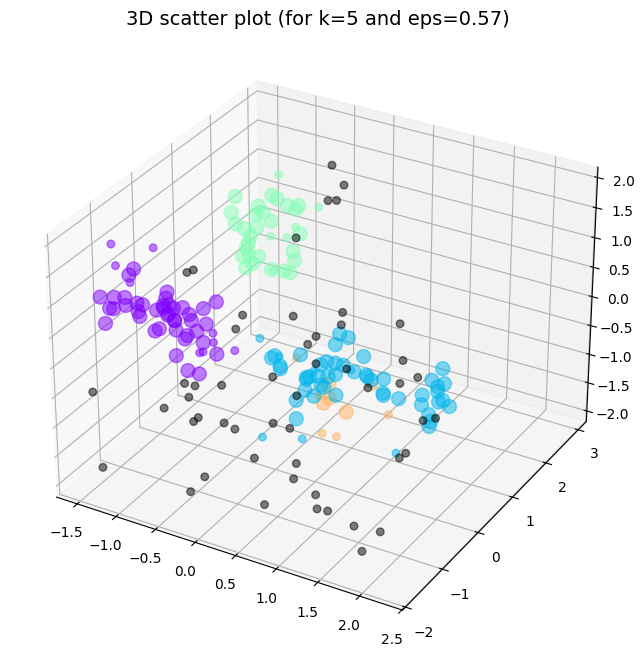

In [31]:
# We plot a 3D scatter plot of the data to better examine the clusters.

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection="3d") # Create a 3D subplot (1x1 grid, first position) for plotting

colors = cm.rainbow(np.linspace(0, 1, len(unique_db_labels)))

for label, color in zip(unique_db_labels, colors):
    if label == -1: # Check if the current label represents noise in DBSCAN
        color="k" # Set the color to black for noise points
    
    cluster_member_msk = (db_labels==label) # Create a boolean mask selecting points whose DBSCAN label equals the current cluster label

    core_datapoints = x_scaled_db[cluster_member_msk & core_sample_msk] # Select core points of the current cluster
    ax.scatter(core_datapoints[:, 0], core_datapoints[:, 1], core_datapoints[:, 2], s=100, c=[color], marker="o", alpha=0.5) 
    border = x_scaled_db[cluster_member_msk & ~core_sample_msk] # Select border points of the current cluster
    ax.scatter(border[:, 0], border[:, 1], border[:, 2], s=30, c=[color], marker="o", alpha=0.5)

plt.title(f"3D scatter plot (for k={k} and eps={epsilon})", fontsize=14)
    

##### The Silhouette Score obtained for this clustering is 0.24, which indicates a relatively weak but still meaningful cluster structure

In [32]:
silhouette_score(x_scaled_db, db_labels)

0.24163687122504832